<a href="https://colab.research.google.com/github/Yahir-7/GeoPandas/blob/main/Exsiting_Noise_Pollution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

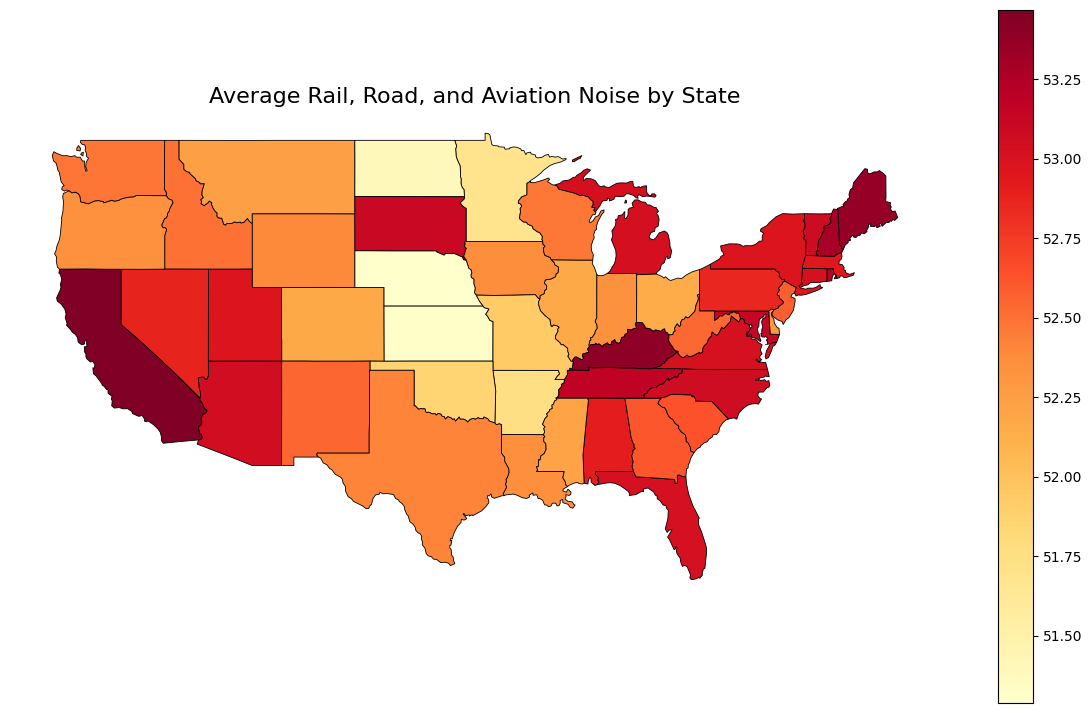

In [5]:
# Run once
# !pip install geopandas rasterio pandas numpy matplotlib

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import os
import matplotlib.pyplot as plt
from rasterio.plot import show

folder = "/content"
results = []

for file in os.listdir(folder):
    if file.endswith(".tif"):
        path = os.path.join(folder, file)
        state = file.split("_")[0]   # gets VA, TX, TN, etc.

        with rasterio.open(path) as src:
            data = src.read(1)

            # clean raster values
            if src.nodata is not None:
                data = data[data != src.nodata]

            data = data[np.isfinite(data)]
            data = data[data > 0]

            results.append({
                "state": state,
                "mean_noise": data.mean(),
                "median_noise": np.median(data),
                "min_noise": data.min(),
                "max_noise": data.max()
            })

noise_df = pd.DataFrame(results)

# Load US states GeoJSON
url = "https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/us-states.json"
state_geo = gpd.read_file(url)

# Merge noise data with the map while only keeping states that exist in noise_df
merged = state_geo.merge(
    noise_df,
    left_on="id",
    right_on="state",
    how="inner"
)
# Plot mean noise by state
fig, ax = plt.subplots(figsize=(15, 9))

merged.plot(
    column="mean_noise",
    cmap="YlOrRd",
    linewidth=0.6,
    edgecolor="black",
    legend=True,
    ax=ax
)

ax.set_title("Average Rail, Road, and Aviation Noise by State", fontsize=16)
ax.axis("off")

plt.show()